In [1]:
import pandas as pd
merged_df_with_diagnosis = pd.read_csv('merged_data.csv')

In [2]:
print(merged_df_with_diagnosis['Diagnosis'].value_counts())

Diagnosis
AD         141
Control    118
Name: count, dtype: int64


In [3]:
# --- FILTER DATA: Only include AD and Control diagnoses ---
filtered_df = merged_df_with_diagnosis[
    merged_df_with_diagnosis['Diagnosis'].isin(['AD', 'Control'])
]

# --- SPLIT FEATURES AND LABELS ---
# Drop identifier and target columns
X = filtered_df.drop(columns=['sample_id', 'Diagnosis'])
# Binary labels: AD = 1, Control = 0
y = filtered_df['Diagnosis'].map({'AD': 1, 'Control': 0})

# --- TRAIN/TEST SPLIT AND FEATURE SCALING ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

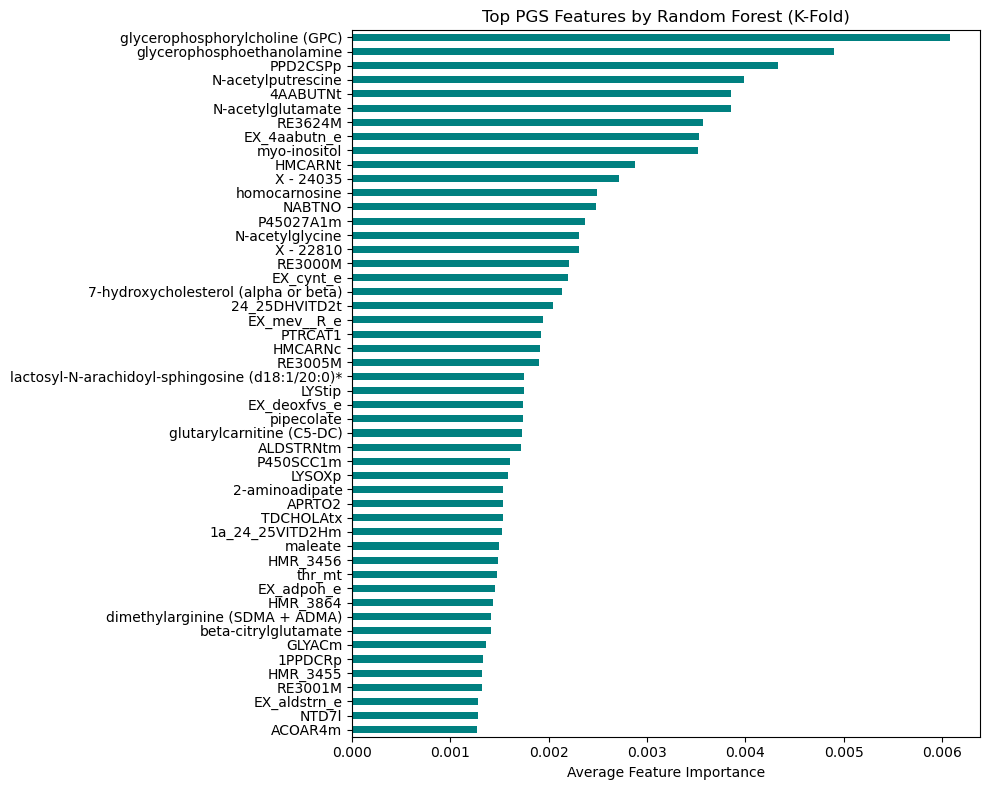

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# --- K-Fold Configuration ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Initialize list to store feature importances ---
feature_importances = []

# --- Train Random Forest on each fold and collect feature importances ---
for train_index, test_index in kf.split(X_train_scaled, y_train):
    X_fold_train = X_train_scaled[train_index]
    y_fold_train = y_train.iloc[train_index]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_fold_train, y_fold_train)

    feature_importances.append(rf.feature_importances_)

# --- Compute average importance across folds ---
avg_importances = np.mean(feature_importances, axis=0)

# --- Convert to pandas Series and sort descending ---
feat_importances = pd.Series(avg_importances, index=X.columns).sort_values(ascending=False)

# --- Visualize top 50 features ---
feat_importances.head(50).plot(
    kind='barh',
    figsize=(10, 8),
    color='teal'
)
plt.title("Top PGS Features by Random Forest (K-Fold)")
plt.xlabel("Average Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

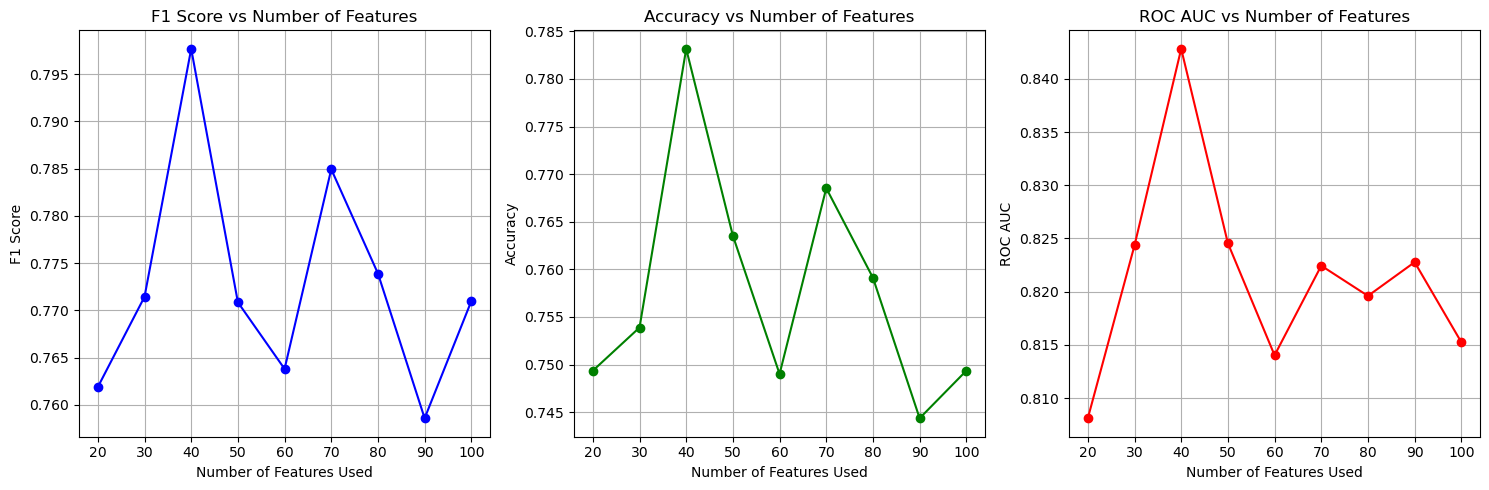

In [5]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# --- Initialize lists to store metrics ---
f1_scores = []
accuracy_scores = []
auc_scores = []

# Feature subset sizes to test (from 20 to 100, step 10)
feature_counts = list(range(20, 101, 10))

# --- Train Random Forest with increasing number of top features ---
for i in feature_counts:
    # Select top-i features
    selected_features = list(feat_importances.head(i).index)
    selected_indices = [X.columns.get_loc(feat) for feat in selected_features]
    X_selected = X_train_scaled[:, selected_indices]

    fold_f1 = []
    fold_accuracy = []
    fold_auc = []

    # Cross-validation for current feature subset
    for train_index, test_index in kf.split(X_selected, y_train):
        X_fold_train = X_selected[train_index]
        y_fold_train = y_train.iloc[train_index]
        X_fold_test = X_selected[test_index]
        y_fold_test = y_train.iloc[test_index]

        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_fold_train, y_fold_train)

        y_pred = rf.predict(X_fold_test)
        y_pred_prob = rf.predict_proba(X_fold_test)[:, 1]

        fold_f1.append(f1_score(y_fold_test, y_pred))
        fold_accuracy.append(accuracy_score(y_fold_test, y_pred))
        fold_auc.append(roc_auc_score(y_fold_test, y_pred_prob))

    # Average metric across folds
    f1_scores.append(np.mean(fold_f1))
    accuracy_scores.append(np.mean(fold_accuracy))
    auc_scores.append(np.mean(fold_auc))

# --- Visualize results ---
plt.figure(figsize=(15, 5))

# F1 Score vs. Number of Features
plt.subplot(1, 3, 1)
plt.plot(feature_counts, f1_scores, marker='o', color='blue')
plt.title('F1 Score vs Number of Features')
plt.xlabel('Number of Features Used')
plt.ylabel('F1 Score')
plt.grid(True)

# Accuracy vs. Number of Features
plt.subplot(1, 3, 2)
plt.plot(feature_counts, accuracy_scores, marker='o', color='green')
plt.title('Accuracy vs Number of Features')
plt.xlabel('Number of Features Used')
plt.ylabel('Accuracy')
plt.grid(True)

# ROC AUC vs. Number of Features
plt.subplot(1, 3, 3)
plt.plot(feature_counts, auc_scores, marker='o', color='red')
plt.title('ROC AUC vs Number of Features')
plt.xlabel('Number of Features Used')
plt.ylabel('ROC AUC')
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# --- Identify best scores and corresponding number of features ---
best_f1 = max(f1_scores)
best_f1_features = feature_counts[f1_scores.index(best_f1)]

best_acc = max(accuracy_scores)
best_acc_features = feature_counts[accuracy_scores.index(best_acc)]

best_auc = max(auc_scores)
best_auc_features = feature_counts[auc_scores.index(best_auc)]

# --- Print results ---
print(f"Highest F1 Score: {best_f1:.4f} (Number of Features: {best_f1_features})")
print(f"Highest Accuracy: {best_acc:.4f} (Number of Features: {best_acc_features})")
print(f"Highest ROC AUC: {best_auc:.4f} (Number of Features: {best_auc_features})")

Highest F1 Score: 0.7977 (Number of Features: 40)
Highest Accuracy: 0.7832 (Number of Features: 40)
Highest ROC AUC: 0.8428 (Number of Features: 40)


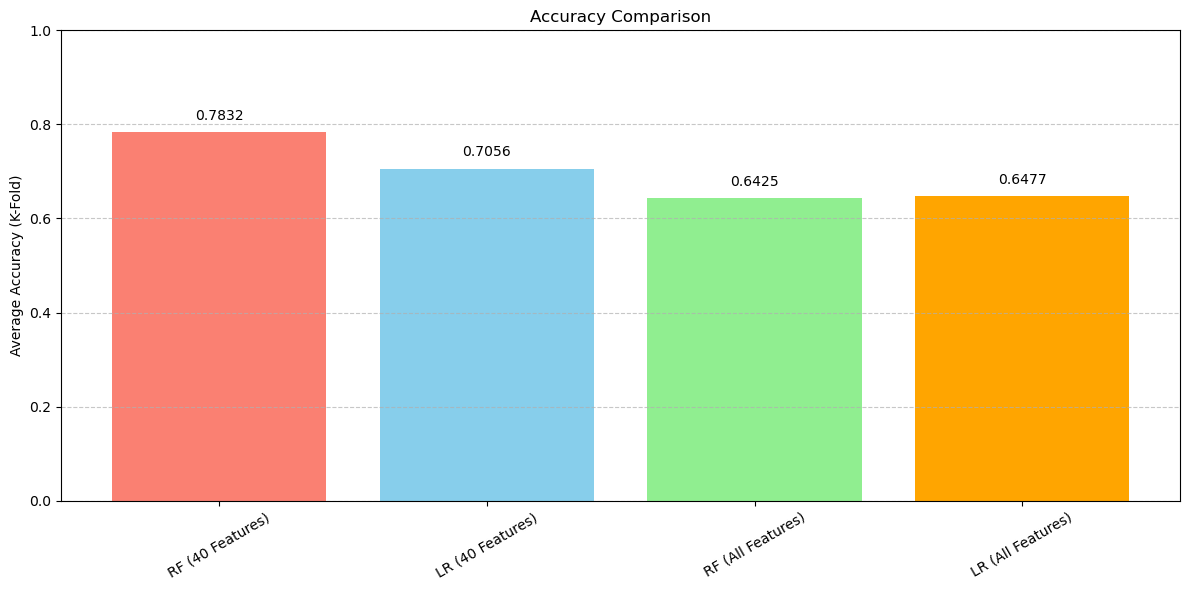

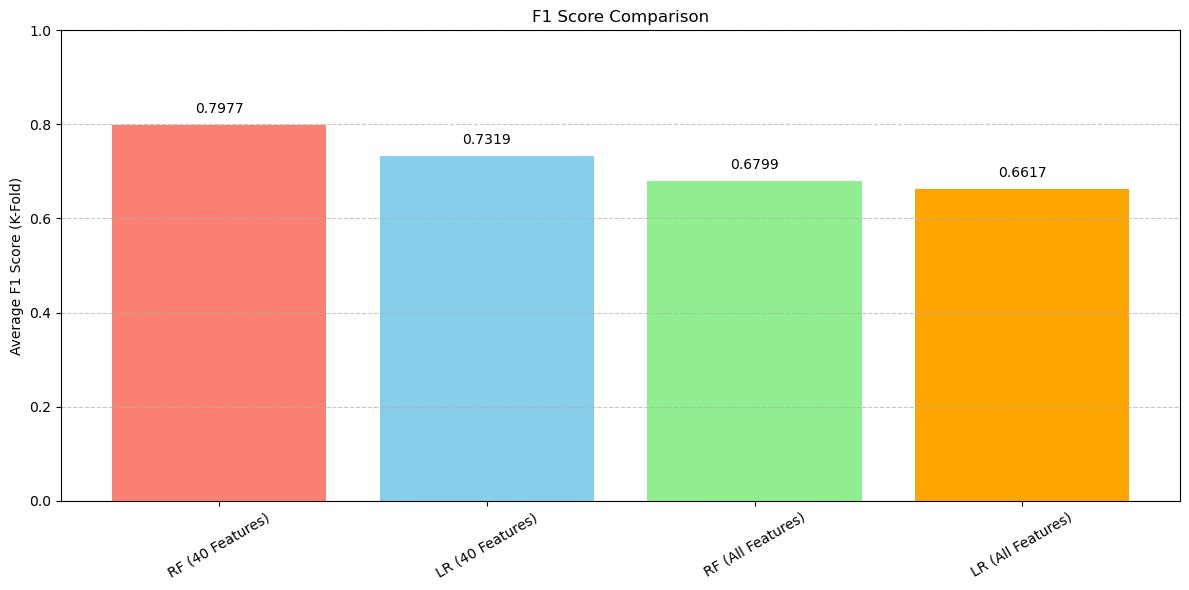

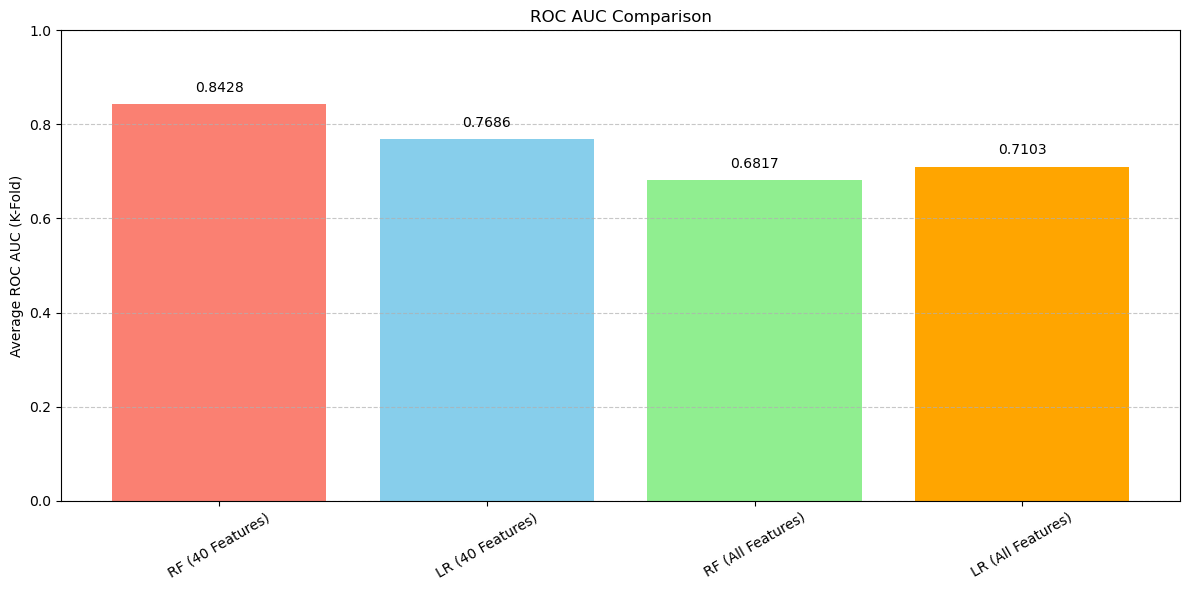

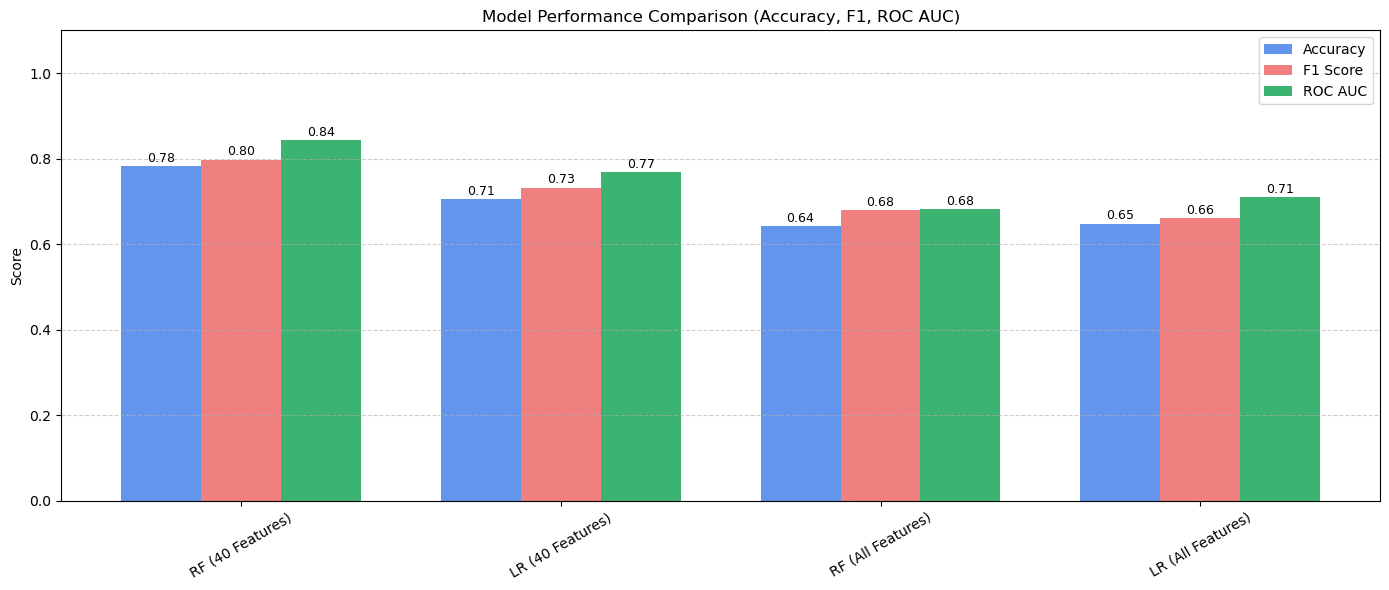

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# --- SELECT TOP FEATURES ---
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# --- CROSS-VALIDATION ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics
rf_top5_accuracies, lr_top5_accuracies = [], []
rf_all_accuracies, lr_all_accuracies = [], []

rf_top5_f1s, lr_top5_f1s = [], []
rf_all_f1s, lr_all_f1s = [], []

rf_top5_aucs, lr_top5_aucs = [], []
rf_all_aucs, lr_all_aucs = [], []

for train_index, test_index in kf.split(X_train_scaled, y_train):
    X_train_fold, X_test_fold = X_train_scaled[train_index], X_train_scaled[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Top 5 Features
    X_train_top5 = X_train_fold[:, top_5_indices]
    X_test_top5 = X_test_fold[:, top_5_indices]

    # Random Forest - Top 5
    rf_top5 = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_top5.fit(X_train_top5, y_train_fold)
    rf_top5_pred = rf_top5.predict(X_test_top5)
    rf_top5_accuracies.append(accuracy_score(y_test_fold, rf_top5_pred))
    rf_top5_f1s.append(f1_score(y_test_fold, rf_top5_pred))
    rf_top5_aucs.append(roc_auc_score(y_test_fold, rf_top5.predict_proba(X_test_top5)[:, 1]))

    # Logistic Regression - Top 5
    lr_top5 = LogisticRegression(random_state=42, max_iter=1000)
    lr_top5.fit(X_train_top5, y_train_fold)
    lr_top5_pred = lr_top5.predict(X_test_top5)
    lr_top5_accuracies.append(accuracy_score(y_test_fold, lr_top5_pred))
    lr_top5_f1s.append(f1_score(y_test_fold, lr_top5_pred))
    lr_top5_aucs.append(roc_auc_score(y_test_fold, lr_top5.predict_proba(X_test_top5)[:, 1]))

    # Random Forest - All Features
    rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_all.fit(X_train_fold, y_train_fold)
    rf_all_pred = rf_all.predict(X_test_fold)
    rf_all_accuracies.append(accuracy_score(y_test_fold, rf_all_pred))
    rf_all_f1s.append(f1_score(y_test_fold, rf_all_pred))
    rf_all_aucs.append(roc_auc_score(y_test_fold, rf_all.predict_proba(X_test_fold)[:, 1]))

    # Logistic Regression - All Features
    lr_all = LogisticRegression(random_state=42, max_iter=1000)
    lr_all.fit(X_train_fold, y_train_fold)
    lr_all_pred = lr_all.predict(X_test_fold)
    lr_all_accuracies.append(accuracy_score(y_test_fold, lr_all_pred))
    lr_all_f1s.append(f1_score(y_test_fold, lr_all_pred))
    lr_all_aucs.append(roc_auc_score(y_test_fold, lr_all.predict_proba(X_test_fold)[:, 1]))

# --- CALCULATE MEAN SCORES ---
avg_accuracies = [
    np.mean(rf_top5_accuracies),
    np.mean(lr_top5_accuracies),
    np.mean(rf_all_accuracies),
    np.mean(lr_all_accuracies)
]

avg_f1s = [
    np.mean(rf_top5_f1s),
    np.mean(lr_top5_f1s),
    np.mean(rf_all_f1s),
    np.mean(lr_all_f1s)
]

avg_aucs = [
    np.mean(rf_top5_aucs),
    np.mean(lr_top5_aucs),
    np.mean(rf_all_aucs),
    np.mean(lr_all_aucs)
]

# --- PLOT METRICS SEPARATELY ---
models = [f'RF ({best_acc_features} Features)', f'LR ({best_acc_features} Features)', 'RF (All Features)', 'LR (All Features)']
colors = ['salmon', 'skyblue', 'lightgreen', 'orange']

# Accuracy
plt.figure(figsize=(12, 6))
bars = plt.bar(models, avg_accuracies, color=colors)
plt.ylabel('Average Accuracy (K-Fold)')
plt.title('Accuracy Comparison')
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, avg_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.4f}', ha='center', va='bottom')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# F1 Score
plt.figure(figsize=(12, 6))
bars = plt.bar(models, avg_f1s, color=colors)
plt.ylabel('Average F1 Score (K-Fold)')
plt.title('F1 Score Comparison')
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, f1 in zip(bars, avg_f1s):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.4f}', ha='center', va='bottom')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ROC AUC
plt.figure(figsize=(12, 6))
bars = plt.bar(models, avg_aucs, color=colors)
plt.ylabel('Average ROC AUC (K-Fold)')
plt.title('ROC AUC Comparison')
plt.ylim([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, auc in zip(bars, avg_aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.4f}', ha='center', va='bottom')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- COMBINED METRICS PLOT ---
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, avg_accuracies, width=width, label='Accuracy', color='cornflowerblue')
plt.bar(x, avg_f1s, width=width, label='F1 Score', color='lightcoral')
plt.bar(x + width, avg_aucs, width=width, label='ROC AUC', color='mediumseagreen')

# Annotate bars
for i in range(len(models)):
    plt.text(x[i] - width, avg_accuracies[i] + 0.01, f'{avg_accuracies[i]:.2f}', ha='center', fontsize=9)
    plt.text(x[i], avg_f1s[i] + 0.01, f'{avg_f1s[i]:.2f}', ha='center', fontsize=9)
    plt.text(x[i] + width, avg_aucs[i] + 0.01, f'{avg_aucs[i]:.2f}', ha='center', fontsize=9)

plt.xticks(x, models, rotation=30)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Performance Comparison (Accuracy, F1, ROC AUC)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('combined_scores_graph.png', format='png')
plt.show()

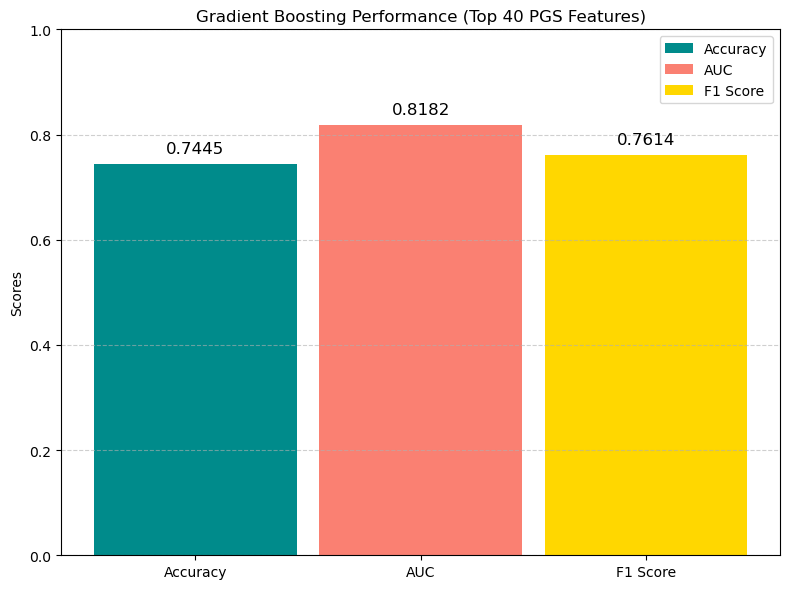

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

# --- Select top features based on previous importance ranking ---
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Prepare dataset using only top features
X_top5 = X_train_scaled[:, top_5_indices]
y = y_train

# Define Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, random_state=42
)

# 5-Fold Stratified Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb_accuracies = []
gb_aucs = []
gb_f1s = []

for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Train model
    gb_model.fit(X_train_fold, y_train_fold)

    # Predictions and probabilities
    y_pred = gb_model.predict(X_test_fold)
    y_pred_prob = gb_model.predict_proba(X_test_fold)[:, 1]

    # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred)
    auc = roc_auc_score(label_binarize(y_test_fold, classes=[0, 1]), y_pred_prob)
    f1 = f1_score(y_test_fold, y_pred)

    gb_accuracies.append(acc)
    gb_aucs.append(auc)
    gb_f1s.append(f1)

# --- Compute mean metrics across folds ---
mean_gb_acc = np.mean(gb_accuracies)
mean_gb_auc = np.mean(gb_aucs)
mean_gb_f1 = np.mean(gb_f1s)

# --- Visualization ---
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.9

# Plot metrics as bars
ax.bar(0, mean_gb_acc, width, color='darkcyan', label='Accuracy')
ax.bar(1, mean_gb_auc, width, color='salmon', label='AUC')
ax.bar(2, mean_gb_f1, width, color='gold', label='F1 Score')

# Labels and titles
ax.set_ylabel('Scores')
ax.set_title(f'Gradient Boosting Performance (Top {best_acc_features} PGS Features)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Accuracy', 'AUC', 'F1 Score'])
ax.set_ylim([0, 1])
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
ax.text(0, mean_gb_acc + 0.02, f"{mean_gb_acc:.4f}", ha='center', fontsize=12)
ax.text(1, mean_gb_auc + 0.02, f"{mean_gb_auc:.4f}", ha='center', fontsize=12)
ax.text(2, mean_gb_f1 + 0.02, f"{mean_gb_f1:.4f}", ha='center', fontsize=12)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()


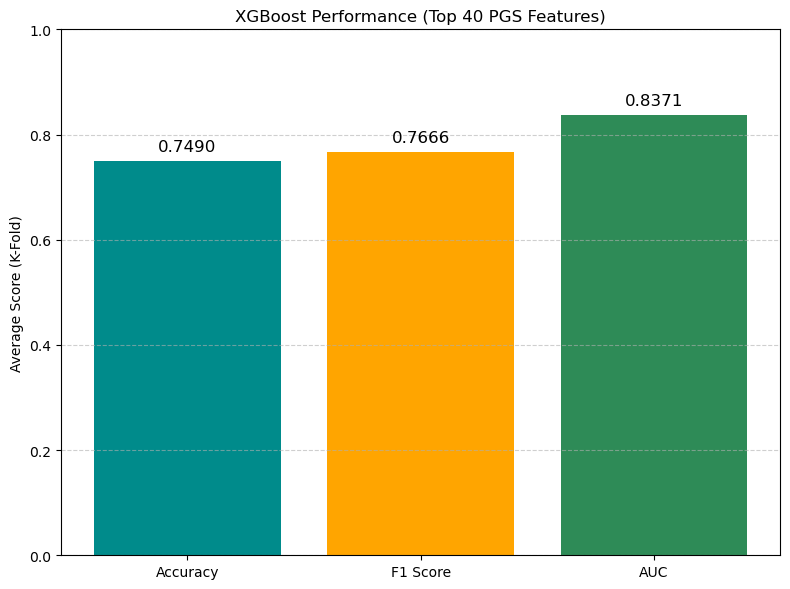

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Select top features
top_5_features = feat_importances.head(best_acc_features).index
top_5_indices = [X.columns.get_loc(col) for col in top_5_features]

# Prepare dataset with top features
X_top5 = X_train_scaled[:, top_5_indices]
y = y_train

# XGBoost classifier (use_label_encoder removed)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'  # keep a valid eval metric
)

# 5-Fold Stratified CV
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_accuracies = []
xgb_f1_scores = []
xgb_auc_scores = []

for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    xgb_model.fit(X_train_fold, y_train_fold)
    y_pred = xgb_model.predict(X_test_fold)
    y_prob = xgb_model.predict_proba(X_test_fold)[:, 1]

    # Metrics
    xgb_accuracies.append(accuracy_score(y_test_fold, y_pred))
    xgb_f1_scores.append(f1_score(y_test_fold, y_pred))
    xgb_auc_scores.append(roc_auc_score(y_test_fold, y_prob))

# Compute mean metrics
mean_xgb_acc = np.mean(xgb_accuracies)
mean_xgb_f1 = np.mean(xgb_f1_scores)
mean_xgb_auc = np.mean(xgb_auc_scores)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
metrics = ['Accuracy', 'F1 Score', 'AUC']
values = [mean_xgb_acc, mean_xgb_f1, mean_xgb_auc]
colors = ['darkcyan', 'orange', 'seagreen']

ax.bar(metrics, values, color=colors)
ax.set_ylim([0, 1])
ax.set_ylabel('Average Score (K-Fold)')
ax.set_title(f'XGBoost Performance (Top {best_acc_features} PGS Features)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

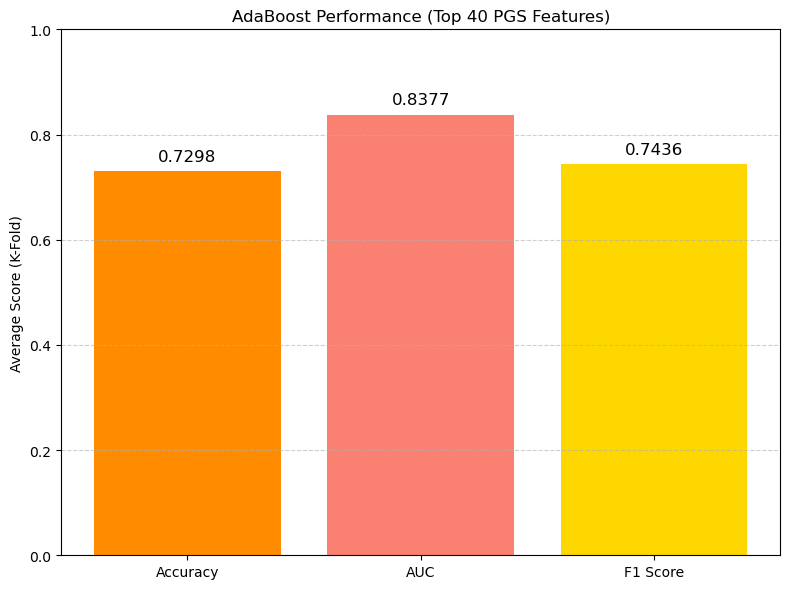

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Select top features
top_features = feat_importances.head(best_acc_features).index
top_indices = [X.columns.get_loc(col) for col in top_features]

X_top5 = X_train_scaled[:, top_indices]
y = y_train

# AdaBoost classifier
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

# 5-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies, aucs, f1s = [], [], []

for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    ada_model.fit(X_train_fold, y_train_fold)
    y_pred = ada_model.predict(X_test_fold)
    y_prob = ada_model.predict_proba(X_test_fold)[:, 1]

    # Compute metrics
    accuracies.append(accuracy_score(y_test_fold, y_pred))
    aucs.append(roc_auc_score(y_test_fold, y_prob))
    f1s.append(f1_score(y_test_fold, y_pred))

# Mean metrics
mean_acc = np.mean(accuracies)
mean_auc = np.mean(aucs)
mean_f1 = np.mean(f1s)

# Visualization
fig, ax = plt.subplots(figsize=(8,6))
metrics = ['Accuracy', 'AUC', 'F1 Score']
values = [mean_acc, mean_auc, mean_f1]
colors = ['darkorange', 'salmon', 'gold']

ax.bar(metrics, values, color=colors)
ax.set_ylim([0, 1])
ax.set_ylabel('Average Score (K-Fold)')
ax.set_title(f'AdaBoost Performance (Top {best_acc_features} PGS Features)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

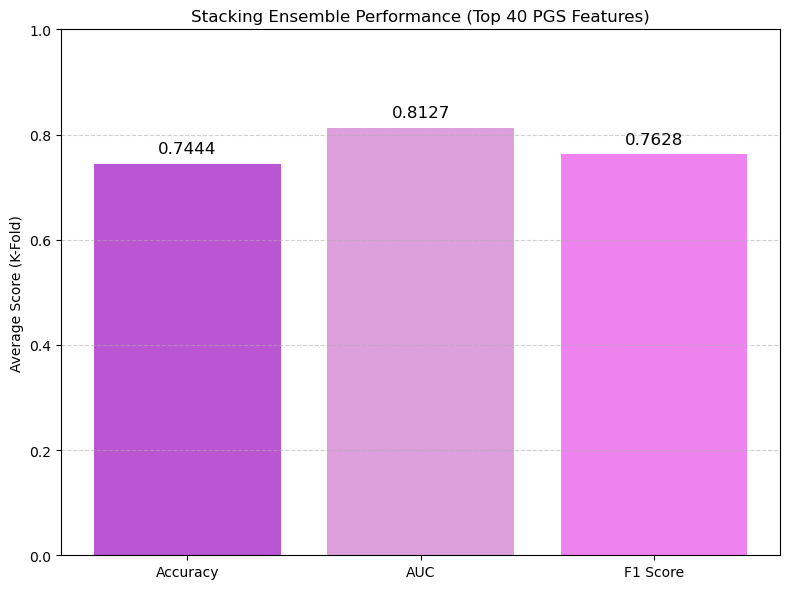

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Top features
top_features = feat_importances.head(best_acc_features).index
top_indices = [X.columns.get_loc(col) for col in top_features]

X_top5 = X_train_scaled[:, top_indices]
y = y_train

# Stacking ensemble
base_learners = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier())
]

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=False
)

# 5-Fold cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies, aucs, f1s = [], [], []

for train_idx, test_idx in kf.split(X_top5, y):
    X_train_fold, X_test_fold = X_top5[train_idx], X_top5[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    stack_model.fit(X_train_fold, y_train_fold)
    y_pred = stack_model.predict(X_test_fold)
    y_prob = stack_model.predict_proba(X_test_fold)[:, 1]

    # Compute metrics
    accuracies.append(accuracy_score(y_test_fold, y_pred))
    aucs.append(roc_auc_score(y_test_fold, y_prob))
    f1s.append(f1_score(y_test_fold, y_pred))

# Mean metrics
mean_acc = np.mean(accuracies)
mean_auc = np.mean(aucs)
mean_f1 = np.mean(f1s)

# Visualization
fig, ax = plt.subplots(figsize=(8,6))
metrics = ['Accuracy', 'AUC', 'F1 Score']
values = [mean_acc, mean_auc, mean_f1]
colors = ['mediumorchid', 'plum', 'violet']

ax.bar(metrics, values, color=colors)
ax.set_ylim([0, 1])
ax.set_ylabel('Average Score (K-Fold)')
ax.set_title(f'Stacking Ensemble Performance (Top {best_acc_features} PGS Features)')
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()